<a href="https://colab.research.google.com/github/ROSILENE05/plataforma-inteligente-core/blob/main/Plataforma_Inteligente.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Plataforma_Inteligente**

**Título do Projeto:** Plataforma_Inteligente

**Autor/Líder (PM - Product/Project Manager):** Rosilene

**Resumo Executivo**

Microsserviço inteligente projetado para pequenas e médias construtoras para automatizar o controle de almoxarifado, empréstimo de ferramentas e gestão de insumos. Integra autenticação biométrica facial e uma interface conversacional baseada em RAG (Retrieval-Augmented Generation) para consulta em tempo real de normas técnicas, relatórios de obras e status de estoque.

**Problema (Contexto)**

Pequenas e médias empresas sofrem com perdas financeiras e atrasos devido a falhas na comunicação entre o escritório e o canteiro de obras. O almoxarifado costuma operar com controle manual ou planilhas, resultando em furtos, desperdícios, falta de rastreabilidade na retirada de ferramentas/materiais e ausência de dados confiáveis em tempo real para os engenheiros e gestores.

**Proposta de Solução**

Microsserviço de Visão Computacional: Reconhecimento facial no app Flutter para retirada/devolução rápida e segura de itens no almoxarifado sem uso de crachás ou senhas físicas.

Assistente RAG com LLM: Backend Django com banco vetorial para busca semântica em manuais de equipamentos, relatórios diários de obras e auditorias de estoque.

Painel de Controle Centralizado: Frontend web React/Vite para relatórios analíticos, alertas de estoque mínimo e auditoria em tempo real.

**Metas e Alinhamento Estratégico (OKRs)**

*Objetivo (Onde queremos chegar?):*

Tornar o fluxo de controle de insumos e ferramentas 100% digital, seguro e auditável.

*Resultados-Chave (Como mediremos o progresso?):*

*KR 1:* Reduzir o tempo médio de retirada/devolução de ferramentas no almoxarifado em 70% (de 3 minutos para menos de 45 segundos por operador).

*KR 2:* Diminuir o índice de extravios ou ferramentas não devolvidas a menos de 1% no primeiro trimestre de operação.

**Gestão de Riscos e Mitigação**

*Risco Técnico:* Falhas na leitura de reconhecimento facial devido a poeira, variação de iluminação ou uso de EPIs (óculos, máscaras, capacetes) no canteiro de obras.

*Plano de Mitigação:*

Implementação de pré-processamento de imagem avançado na API de IA e treinamento de modelos com datasets contendo operários com EPIs.

Inclusão de um método de autenticação secundário (PIN numérico ou crachá RFID) como fallback automático caso a confiança da biometria facial esteja abaixo de um limiar configurável (ex: 85%).

**Governança e Metodologia**

*Revisão de Status Semanal (Async Update):* Status enviado em formato de texto nos canais oficiais da equipe. Discussões presenciais/calls são restritas estritamente a bloqueios técnicos complexos.

*Retrospectiva (Post-Mortem):* Realizada obrigatoriamente logo após cada entrega de marco ou em caso de falhas críticas, focada em melhoria contínua e em um ambiente blameless (sem apontar culpados)

**Stack Tecnológico**

*Backend:* Django REST Framework (Python) com versionamento explícito de rotas (/api/v1/...).

*Banco de Dados:* PostgreSQL + extensão pgvector para buscas semânticas via RAG.

*Frontend Web:* React com Vite ou Vue.js.

*App Mobile:* Flutter.

*Infraestrutura:* Docker & Docker Compose com checagem de saúde (Healthcheck) no banco de dados.

*Inteligência Artificial:* Integração com LLMs utilizando RAG.

*Cloud:* AWS / Azure.

*Ambiente de Desenvolvimento:* Google Colab (sandbox - laboratório de testes) e Google Drive para prototipagem de modelos de visão computacional/IA.

**Estrutura de Pastas do Projeto (Padrão Sênior)**

plataforma-inteligente/

├── .devcontainer/         # Configuração para Codespaces (Zero-Install)

├── .github/workflows/     # CI/CD Pipelines (GitHub Actions)

├── configs/               # YAML/JSON centralizando hiperparâmetros e configs de IA

├── docs/                  # Relatório Técnico (Whitepaper) + Diagramas de Arquitetura

├── src/                   # Código-fonte modular

│   ├── backend/           # Django REST Framework (API, modelos, views)

│   ├── ai_core/           # Módulo de Reconhecimento Facial e integração RAG

│   ├── frontend_web/      # Aplicação React com Vite

│   └── mobile_app/        # Aplicativo Flutter (Canteiro de Obras)

├── tests/                 # Testes unitários e de integração (pytest)

├── docker-compose.yml     # Orquestração de containers com Healthcheck

├── .env.example           # Exemplo de variáveis de ambiente seguras

├── README.md              # Vitrine do projeto, badges e documentação de uso

└── LICENSE                # Licença Open Source (MIT)

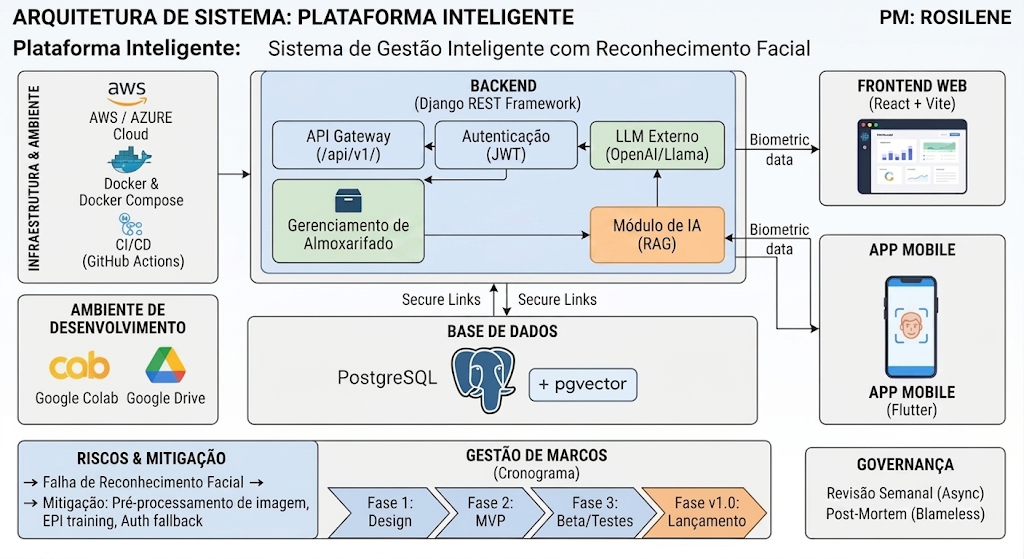

#**Framework (Tier-1)**

Este framework garante a construção de um sistema robusto, escalável e seguro.

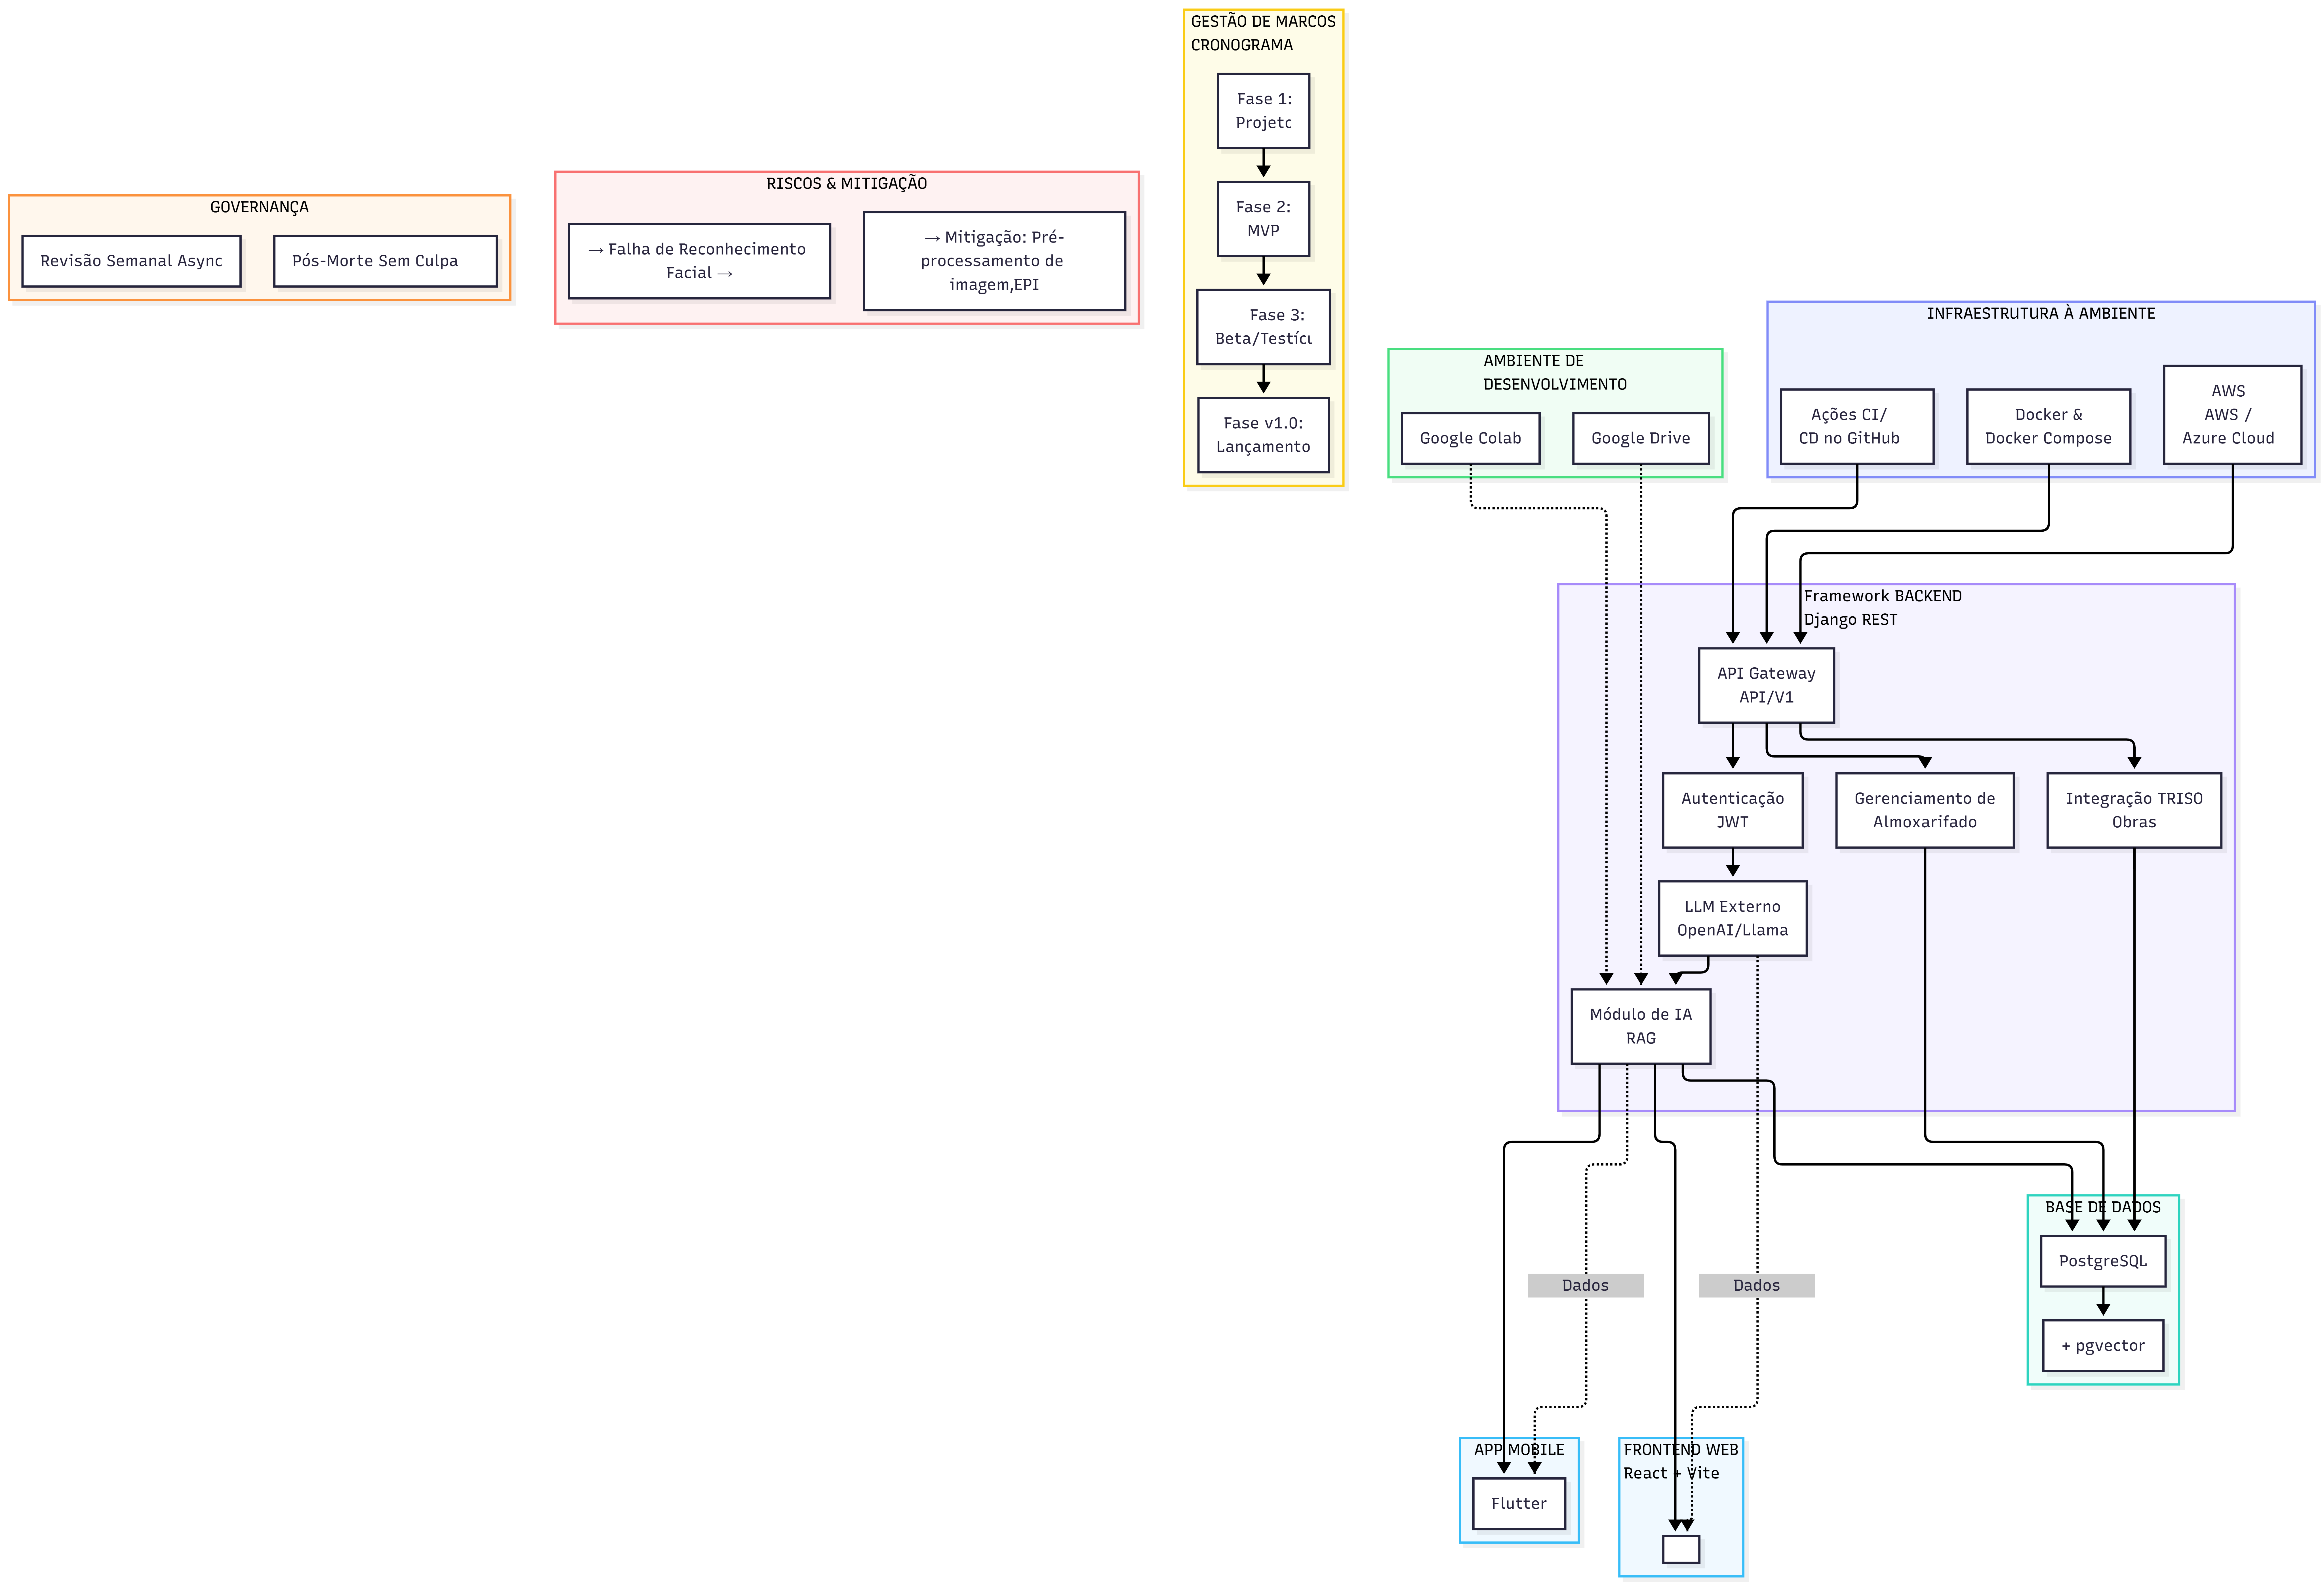

#**Especificação Técnica**

1. Padrão de Arquitetura

Arquitetura em Camadas Orientada a Serviços (Layered Service-Oriented Architecture) desacoplada do framework (Clean Architecture / Hexagonal Ports & Adapters), garantindo que as regras de negócio e de IA permaneçam isoladas da camada HTTP do Django.

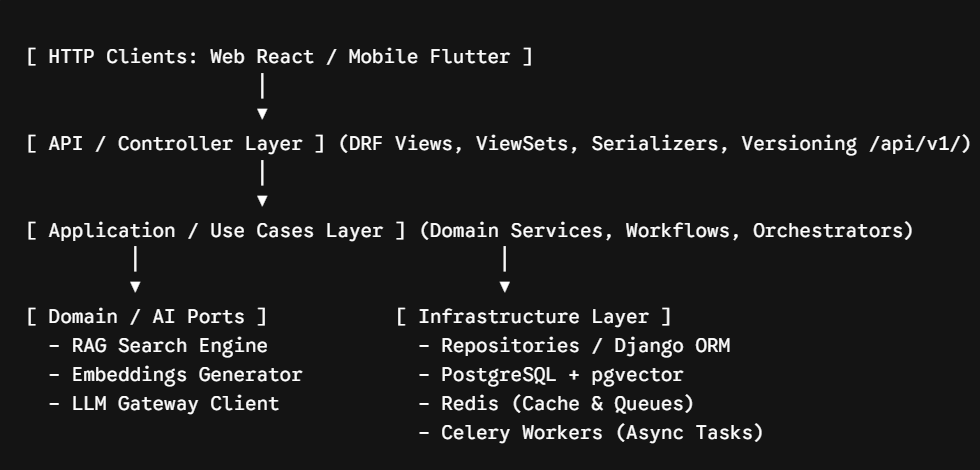

2. Fluxo de Requisição e Ciclo de Vida

O ciclo de vida de uma requisição na API segue o pipeline.

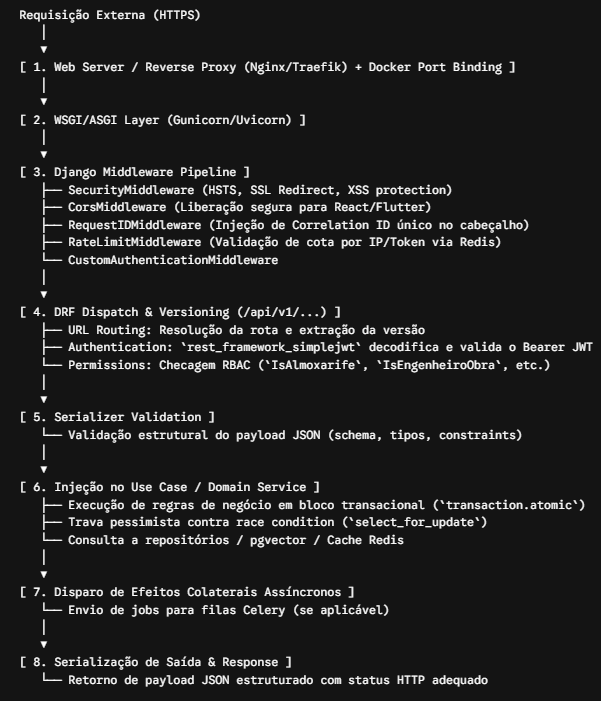

3. Modelagem de Dados e Persistência

O banco de dados relacional é o PostgreSQL 16+, com a extensão pgvector habilitada para armazenamento e indexação de vetores de alta dimensionalidade gerados a partir de relatórios, itens de almoxarifado e notas fiscais.

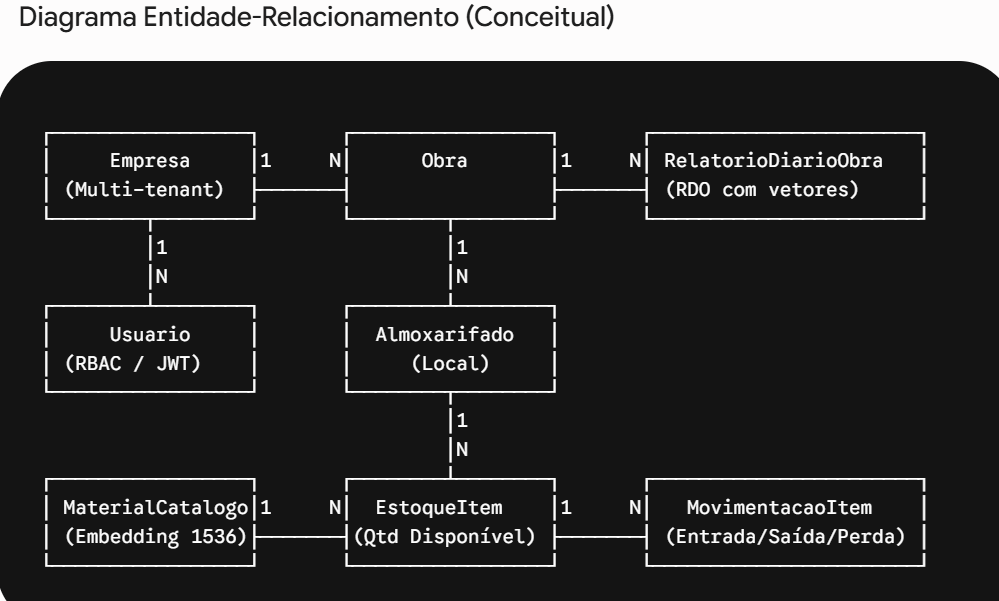

Entidades Principais e Definição de Schemas

In [ ]:
-- Habilitação da extensão de busca vetorial
CREATE EXTENSION IF NOT EXISTS vector;

-- Catálogo de Materiais com Suporte a Busca Semântica
CREATE TABLE core_materialcatalogo (
    id UUID PRIMARY KEY DEFAULT gen_random_uuid(),
    empresa_id UUID NOT NULL REFERENCES core_empresa(id) ON DELETE CASCADE,
    codigo_sku VARCHAR(64) NOT NULL,
    nome VARCHAR(255) NOT NULL,
    descricao TEXT,
    categoria VARCHAR(100),
    unidade_medida VARCHAR(20) NOT NULL, -- UN, KG, M, M3, SACO
    embedding_descricao vector(1536),    -- text-embedding-3-small (OpenAI / Azure OpenAI)
    criado_em TIMESTAMP WITH TIME ZONE DEFAULT CURRENT_TIMESTAMP,
    CONSTRAINT uk_material_sku_empresa UNIQUE (empresa_id, codigo_sku)
);

-- Posição Atual de Estoque por Obra/Almoxarifado
CREATE TABLE core_estoqueitem (
    id UUID PRIMARY KEY DEFAULT gen_random_uuid(),
    almoxarifado_id UUID NOT NULL REFERENCES core_almoxarifado(id) ON DELETE RESTRICT,
    material_id UUID NOT NULL REFERENCES core_materialcatalogo(id) ON DELETE RESTRICT,
    quantidade_disponivel NUMERIC(12, 4) NOT NULL DEFAULT 0.0000,
    quantidade_reservada NUMERIC(12, 4) NOT NULL DEFAULT 0.0000,
    ponto_ressuprimento NUMERIC(12, 4) DEFAULT 0.0000,
    atualizado_em TIMESTAMP WITH TIME ZONE DEFAULT CURRENT_TIMESTAMP,
    CONSTRAINT uk_estoque_local_material UNIQUE (almoxarifado_id, material_id),
    CONSTRAINT chk_quantidade_nao_negativa CHECK (quantidade_disponivel >= 0)
);

-- Movimentações de Entrada, Saída, Transferência e Extravio
CREATE TABLE core_movimentacaoitem (
    id UUID PRIMARY KEY DEFAULT gen_random_uuid(),
    estoque_item_id UUID NOT NULL REFERENCES core_estoqueitem(id) ON DELETE RESTRICT,
    usuario_responsavel_id UUID NOT NULL REFERENCES auth_usuario(id),
    tipo_movimentacao VARCHAR(32) NOT NULL, -- ENTRADA_NF, SAIDA_OBRA, EXTRAVIO, TRANSFERENCIA, DEVOLUCAO
    quantidade NUMERIC(12, 4) NOT NULL,
    motivo_justificativa TEXT,
    foto_comprovante_url VARCHAR(1024),
    criado_em TIMESTAMP WITH TIME ZONE DEFAULT CURRENT_TIMESTAMP
);

-- Relatórios e Feedbacks de Obra para RAG
CREATE TABLE core_relatoriodiarioobra (
    id UUID PRIMARY KEY DEFAULT gen_random_uuid(),
    obra_id UUID NOT NULL REFERENCES core_obra(id) ON DELETE CASCADE,
    data_relatorio DATE NOT NULL,
    conteudo_texto TEXT NOT NULL,
    ocorrencias_materiais TEXT,
    embedding_contextual vector(1536),
    criado_em TIMESTAMP WITH TIME ZONE DEFAULT CURRENT_TIMESTAMP
);

Estratégia de Indexação e Cache
Índices Vetoriais (HNSW):
Para buscas semânticas em sub-segundos:

In [ ]:
CREATE INDEX idx_material_embedding_hnsw
ON core_materialcatalogo
USING hnsw (embedding_descricao vector_cosine_ops)
WITH (m = 16, ef_construction = 64);

Índices Estruturais: B-Tree em chaves estrangeiras compostas (empresa_id, codigo_sku) e índices parciais para materiais com estoque abaixo do ponto de ressuprimento.

Cache em Memória (Redis):

Catálogo Quente: Itens frequentemente consultados em cache com TTL de 30 minutos (chave: cache:catalogo:{empresa_id}).

Invalidation Strategy: Invalidação por padrão de tags/chaves na execução de mutações via signals ou métodos do Service.

4. Comunicação Assíncrona e Filas

A arquitetura utiliza Celery conectado ao Redis (como message broker e result backend) para desonerar o ciclo síncrono da API em operações de IA, ingestão de dados e auditoria.

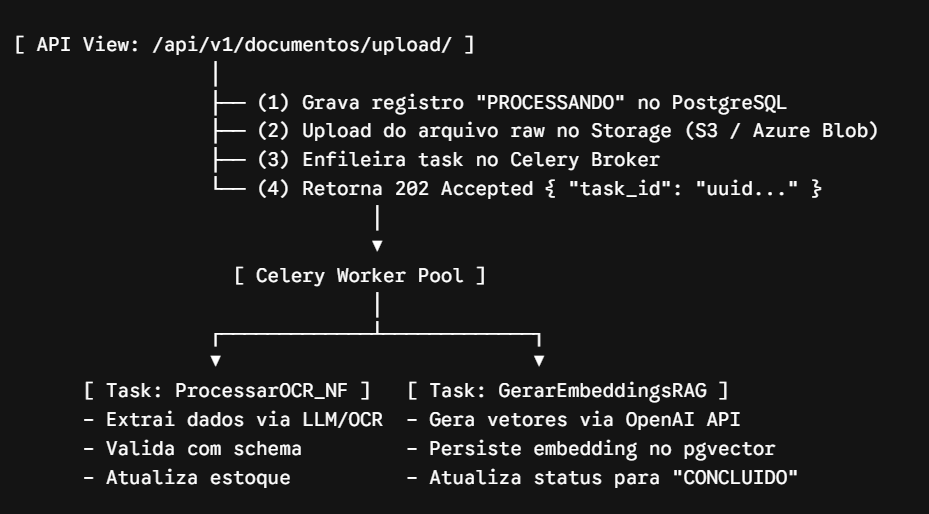

Cenários de Aplicação Assíncrona

1. Ingestão de Notas Fiscais e Comprovantes: Extração de itens, quantidades e valores de arquivos PDF/imagens via OCR e LLM vision.

2. Vetorização de Relatórios e Catálogos: Geração periódica ou sob demanda de vetores semânticos no pgvector.

3. Auditoria e Alertas de Extravio: Algoritmo preditivo que avalia discrepâncias entre saídas de almoxarifado e avanços relatados no RDO da obra.

5. Autenticação, Autorização e Segurança

Autenticação Stateless: django-rest-framework-simplejwt utilizando tokens RS256 (chaves assimétricas) ou HS256 de rotação rápida:

Access Token: Duração de 15 minutos (transmitido no Header Authorization: Bearer <token>).

Refresh Token: Duração de 7 dias, armazenado em HttpOnly, SameSite=Strict, Secure cookies no cliente web ou em Keychain/Keystore no Flutter.

Controle de Acesso Baseado em Papéis (RBAC - Role-Based Access Control):
Implementação de Permissions customizadas no DRF:

ADMINISTRADOR: Gestão total da empresa e tenants.

ENGENHEIRO_GESTOR: Acesso a relatórios, solicitações e visões analíticas de todas as obras da sua alçada.

ALMOXARIFE: Permissão restrita de leitura de catálogo e escrita de movimentações (entrada, saída, inventário) em seu canteiro específico.

MESTRE_OBRA: Solicitação de materiais e apontamento diário de RDO.

Isolamento Multi-tenant: Todas as queries são filtradas automaticamente pelo empresa_id associado ao usuário autenticado, utilizando um custom Manager no Django ORM para evitar vazamento de dados entre empresas.

Segurança de Borda e Rate Limiting:

Limitação de taxa (Throttling) via Redis: 100 requisições/minuto para usuários autenticados, 10 requisições/minuto no endpoint de login.

Sanitização contra XSS e SQL Injection garantida pelo ORM parametrizado e serializadores tipados.

6. Endpoints Principais (API v1)

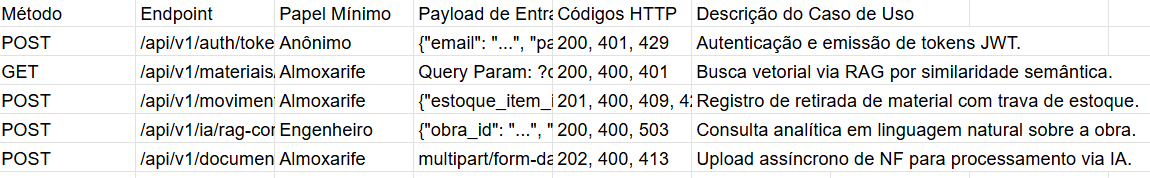

Contratos de Dados (Exemplos de JSON)

1. Registro de Saída com Alerta de Divergência (POST /api/v1/movimentacoes/saida/)

Payload de Requisição:

JSON

In [ ]:
{
  "almoxarifado_id": "8f3b2a54-6c1e-4d0f-bc1a-5b6d7e8f9a01",
  "material_id": "4e1a9b82-2d3f-4e5a-9a8b-1c2d3e4f5a6b",
  "quantidade": 15.0000,
  "tipo_movimentacao": "SAIDA_OBRA",
  "destino_etapa": "Fundação Bloco B",
  "solicitante_id": "1a2b3c4d-5e6f-7a8b-9c0d-1e2f3a4b5c6d",
  "motivo_justificativa": "Concretagem dos pilares da fundação"
}

Payload de Resposta (Status 201 Created):

JSON

In [ ]:
{
  "status": "sucesso",
  "dados": {
    "movimentacao_id": "7b8c9d0e-1f2a-3b4c-5d6e-7f8a9b0c1d2e",
    "material": "Cimento CP II-E-32 - Saco 50kg",
    "quantidade_movimentada": 15.0,
    "saldo_remanescente": 35.0,
    "alerta_ressuprimento": true,
    "mensagem_alerta": "Estoque atingiu o ponto crítico de ressuprimento (limite: 40.0).",
    "registrado_em": "2026-08-21T12:25:56-03:00"
  }
}

2. Consulta Semântica RAG (POST /api/v1/ia/rag-consulta/)
Payload de Requisição:

JSON

In [ ]:
{
  "obra_id": "9a8b7c6d-5e4f-3a2b-1c0d-9e8f7a6b5c4d",
  "pergunta": "Qual foi o consumo de barras de aço CA-50 na última semana e tivemos desvios relatados?"
}

Payload de Resposta (Status 200 OK):

JSON

In [ ]:
{
  "pergunta": "Qual foi o consumo de barras de aço CA-50 na última semana e tivemos desvios relatados?",
  "resposta_sintetizada": "Na última semana foram retiradas 120 barras de aço CA-50 10mm do almoxarifado central. No RDO do dia 18/08, foi reportado descarte por corte incorreto de 8 barras na armação da laje 2.",
  "fontes_consultadas": [
    {
      "tipo": "MOVIMENTACAO_ESTOQUE",
      "referencia_id": "2c3d4e5f-6a7b-8c9d-0e1f-2a3b4c5d6e7f",
      "data": "2026-08-16"
    },
    {
      "tipo": "RELATORIO_DIARIO_OBRA",
      "referencia_id": "f1e2d3c4-b5a6-7890-1234-56789abcdef0",
      "data": "2026-08-18",
      "score_similaridade": 0.892
    }
  ]
}

7. Tratamento de Erros, Casos de Borda e Observabilidade

Tratamento de Casos de Borda Críticos

1. Concorrência de Estoque (Race Condition):
Múltiplas requisições simultâneas debitando o mesmo material são tratadas na camada de serviço com select_for_update() dentro de uma transação atômica do Django ORM:

Python

In [ ]:
# domain/services/estoque.py
from django.db import transaction
from core.exceptions import SaldoInsuficienteException

@transaction.atomic
def registrar_saida(estoque_item_id, quantidade):
    # Bloqueio pessimista no nível do banco (FOR UPDATE)
    estoque = EstoqueItem.objects.select_for_update().get(id=estoque_item_id)

    if estoque.quantidade_disponivel < quantidade:
        raise SaldoInsuficienteException(
            f"Saldo disponível ({estoque.quantidade_disponivel}) é inferior à saída requisitada ({quantidade})."
        )

    estoque.quantidade_disponivel -= quantidade
    estoque.save()
    return estoque

Falha ou Timeout no Provedor de IA (Resiliência do RAG):

Chamadas ao provedor de LLM/Embeddings possuem timeout rígido de 5 segundos.

Padrão Circuit Breaker implementado: caso 5 falhas consecutivas ocorram, o sistema degrada graciosamente para busca textual clássica (ILIKE / PostgreSQL Full-Text Search) sem travar a interface do usuário.

Estrutura de Resposta de Erro Padronizada (RFC 7807)

JSON

In [ ]:
{
  "tipo": "https://api.plataformainteligente.com/erros/saldo-insuficiente",
  "titulo": "Conflito de Estoque",
  "status": 409,
  "detalhe": "Saldo disponível (4.0) é inferior à saída requisitada (10.0).",
  "codigo_erro": "ESTOQUE_SALDO_INSUFICIENTE",
  "correlation_id": "c73a5a8f-2879-4d64-9a84-9dbb1842d098",
  "timestamp": "2026-08-21T12:25:56Z"
}

Observabilidade e Logs Estruturados

Logs Estruturados em JSON (stdout via structlog/python-json-logger):

Permite indexação direta no CloudWatch, Datadog ou ElasticSearch:

JSON

In [ ]:
{
  "timestamp": "2026-08-21T12:25:56.102Z",
  "level": "INFO",
  "logger": "services.estoque",
  "correlation_id": "c73a5a8f-2879-4d64-9a84-9dbb1842d098",
  "empresa_id": "8f3b2a54-6c1e-4d0f-bc1a-5b6d7e8f9a01",
  "usuario_id": "1a2b3c4d-5e6f-7a8b-9c0d-1e2f3a4b5c6d",
  "action": "DEBITO_ESTOQUE",
  "material_id": "4e1a9b82-2d3f-4e5a-9a8b-1c2d3e4f5a6b",
  "quantidade": 15.0,
  "tempo_execucao_ms": 42.8
}

Monitoramento e Healthcheck:

/health/live: Retorna 200 se a aplicação HTTP estiver respondendo.

/health/ready: Valida conectividade com PostgreSQL (SELECT 1), pgvector (SELECT '[1,2,3]'::vector), Redis e Celery Workers. Se algum falhar, retorna 503 Service Unavailable.

#**Execução**

Framework Tier 1: Engenharia e Implementação da Plataforma_Inteligente

O Framework Tier 1 estabelece as fases fundacionais de arquitetura, banco de dados, motor de regras, integração de inteligência artificial e observabilidade, garantindo rastreabilidade e prontidão para produção.

Matriz de Fases e Entregáveis do Tier 1

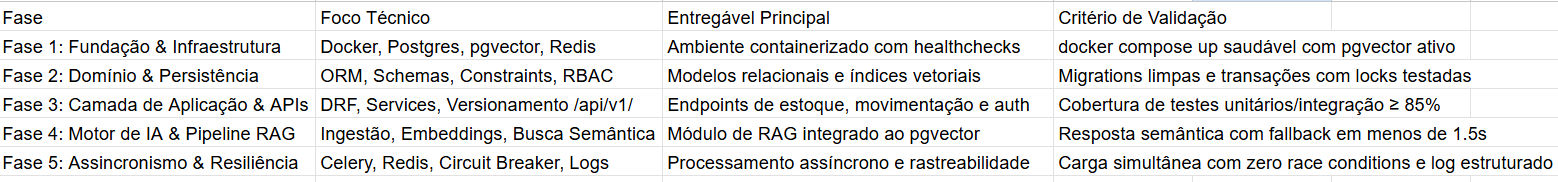

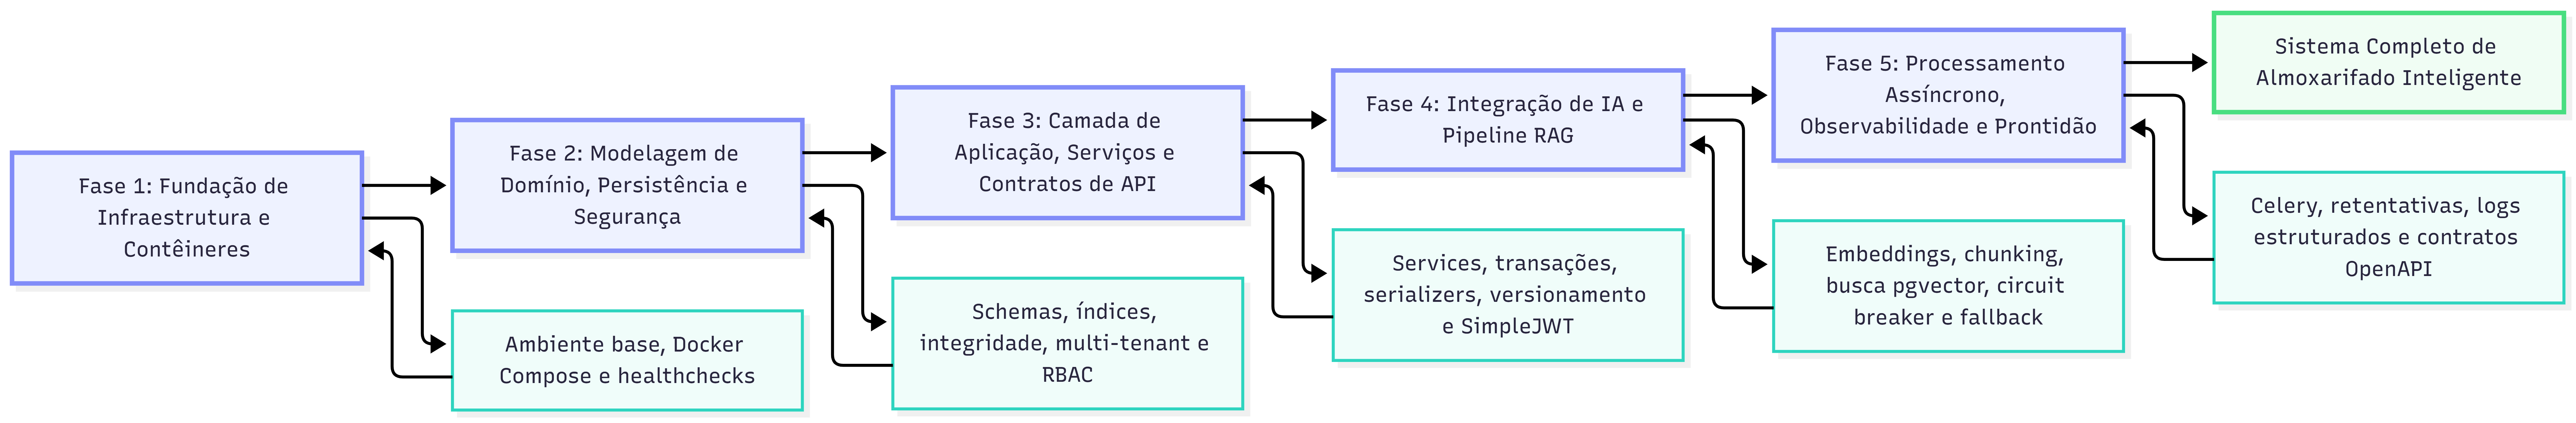

Visão Geral da Sequência de Execução

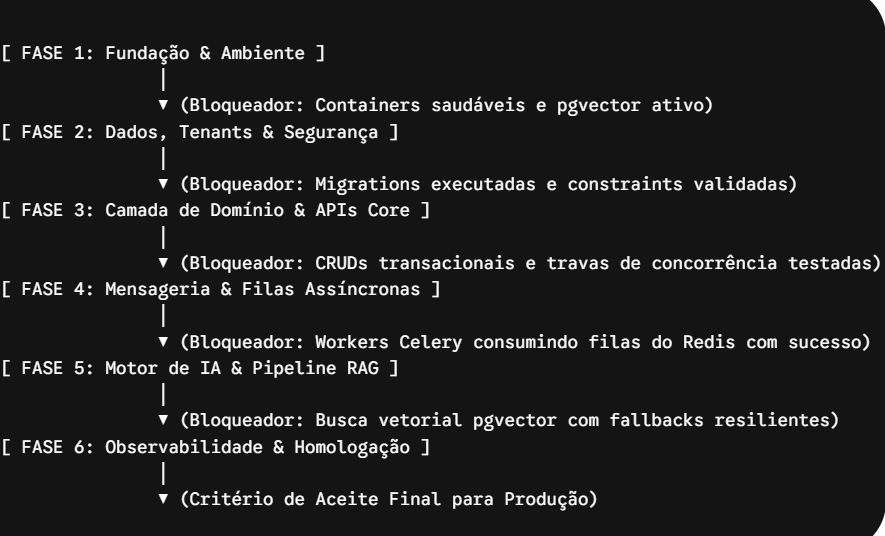

**Fase 1: Fundação, Infraestrutura e Contêineres**

Dockerfile

In [ ]:
# Dockerfile
FROM python:3.12-slim-bookworm

ENV PYTHONUNBUFFERED=1 \
    PYTHONDONTWRITEBYTECODE=1 \
    PIP_NO_CACHE_DIR=off \
    PIP_DISABLE_PIP_VERSION_CHECK=on

WORKDIR /app

RUN apt-get update && apt-get install -y --no-install-recommends \
    build-essential \
    libpq-dev \
    curl \
    netcat-traditional \
    && rm -rf /var/lib/apt/lists/*

COPY requirements.txt .
RUN pip install --upgrade pip && pip install -r requirements.txt

COPY . .

EXPOSE 8000
CMD ["gunicorn", "config.wsgi:application", "--bind", "0.0.0.0:8000", "--workers", "3"]

YAML

In [ ]:
# docker-compose.yml
services:
  db:
    image: pgvector/pgvector:pg16
    container_name: plataforma_db
    environment:
      POSTGRES_DB: plataforma_inteligente_db
      POSTGRES_USER: postgres
      POSTGRES_PASSWORD: postgres_dev_password
    ports:
      - "5432:5432"
    volumes:
      - pgdata:/var/lib/postgresql/data
    healthcheck:
      test: ["CMD-SHELL", "pg_isready -U postgres -d plataforma_inteligente_db && psql -U postgres -d plataforma_inteligente_db -c 'CREATE EXTENSION IF NOT EXISTS vector;'"]
      interval: 5s
      timeout: 5s
      retries: 5

  redis:
    image: redis:7-alpine
    container_name: plataforma_redis
    ports:
      - "6379:6379"
    healthcheck:
      test: ["CMD", "redis-cli", "ping"]
      interval: 5s
      timeout: 3s
      retries: 5

  backend:
    build: .
    container_name: plataforma_backend
    command: python manage.py runserver 0.0.0.0:8000
    volumes:
      - .:/app
    ports:
      - "8000:8000"
    environment:
      - DEBUG=1
      - DATABASE_URL=postgres://postgres:postgres_dev_password@db:5432/plataforma_inteligente_db
      - REDIS_URL=redis://redis:6379/0
      - CELERY_BROKER_URL=redis://redis:6379/1
    depends_on:
      db:
        condition: service_healthy
      redis:
        condition: service_healthy

  celery_worker:
    build: .
    container_name: plataforma_celery
    command: celery -A config worker --loglevel=info
    volumes:
      - .:/app
    environment:
      - DATABASE_URL=postgres://postgres:postgres_dev_password@db:5432/plataforma_inteligente_db
      - CELERY_BROKER_URL=redis://redis:6379/1
    depends_on:
      db:
        condition: service_healthy
      redis:
        condition: service_healthy

volumes:
  pgdata:

*Validação da Fase 1*

Bash

In [ ]:
docker compose up -d
# Validar se todos os containers estão saudáveis
docker compose ps
# Validar extensão pgvector ativa
docker compose exec db psql -U postgres -d plataforma_inteligente_db -c "SELECT extname, extversion FROM pg_extension WHERE extname = 'vector';"

**Fase 2: Modelagem de Dados, Multi-Tenancy e Segurança Base**

Python

In [ ]:
# apps/core/models.py
import uuid
from django.db import models
from django.contrib.auth.models import AbstractUser, BaseUserManager
from pgvector.django import VectorField, HnswIndex

class TenantManager(models.Manager):
    """Manager para isolamento estrito de dados por Empresa (Multi-tenant)."""
    def for_tenant(self, empresa_id):
        return self.filter(empresa_id=empresa_id)

class Empresa(models.Model):
    id = models.UUIDField(primary_key=True, default=uuid.uuid4, editable=False)
    razao_social = models.CharField(max_length=255)
    cnpj = models.CharField(max_length=18, unique=True)
    criado_em = models.DateTimeField(auto_now_add=True)

class Usuario(AbstractUser):
    class Roles(models.TextChoices):
        ADMIN = "ADMINISTRADOR", "Administrador"
        ENGENHEIRO = "ENGENHEIRO_GESTOR", "Engenheiro Gestor"
        ALMOXARIFE = "ALMOXARIFE", "Almoxarife"
        MESTRE_OBRA = "MESTRE_OBRA", "Mestre de Obras"

    id = models.UUIDField(primary_key=True, default=uuid.uuid4, editable=False)
    empresa = models.ForeignKey(Empresa, on_delete=models.CASCADE, related_name="usuarios", null=True, blank=True)
    role = models.CharField(max_length=30, choices=Roles.choices, default=Roles.ALMOXARIFE)

class Obra(models.Model):
    id = models.UUIDField(primary_key=True, default=uuid.uuid4, editable=False)
    empresa = models.ForeignKey(Empresa, on_delete=models.CASCADE, related_name="obras")
    nome = models.CharField(max_length=255)
    endereco = models.TextField()

class Almoxarifado(models.Model):
    id = models.UUIDField(primary_key=True, default=uuid.uuid4, editable=False)
    obra = models.OneToOneField(Obra, on_delete=models.CASCADE, related_name="almoxarifado")
    nome = models.CharField(max_length=100)

class MaterialCatalogo(models.Model):
    id = models.UUIDField(primary_key=True, default=uuid.uuid4, editable=False)
    empresa = models.ForeignKey(Empresa, on_delete=models.CASCADE)
    codigo_sku = models.CharField(max_length=64)
    nome = models.CharField(max_length=255)
    descricao = models.TextField(blank=True)
    unidade_medida = models.CharField(max_length=20)
    embedding_descricao = VectorField(dimensions=1536, null=True, blank=True)

    objects = TenantManager()

    class Meta:
        constraints = [
            models.UniqueConstraint(fields=['empresa', 'codigo_sku'], name='uk_material_sku_empresa')
        ]
        indexes = [
            HnswIndex(
                name='idx_material_embedding_hnsw',
                fields=['embedding_descricao'],
                m=16,
                ef_construction=64,
                opclasses=['vector_cosine_ops']
            )
        ]

class EstoqueItem(models.Model):
    id = models.UUIDField(primary_key=True, default=uuid.uuid4, editable=False)
    almoxarifado = models.ForeignKey(Almoxarifado, on_delete=models.RESTRICT, related_name="itens_estoque")
    material = models.ForeignKey(MaterialCatalogo, on_delete=models.RESTRICT)
    quantidade_disponivel = models.DecimalField(max_digits=12, decimal_places=4, default=0.0)
    ponto_ressuprimento = models.DecimalField(max_digits=12, decimal_places=4, default=0.0)

    class Meta:
        constraints = [
            models.UniqueConstraint(fields=['almoxarifado', 'material'], name='uk_estoque_local_material'),
            models.CheckConstraint(check=models.Q(quantidade_disponivel__gte=0), name='chk_quantidade_nao_negativa')
        ]

class MovimentacaoItem(models.Model):
    class Tipo(models.TextChoices):
        ENTRADA_NF = "ENTRADA_NF", "Entrada via NF"
        SAIDA_OBRA = "SAIDA_OBRA", "Saída para Obra"
        EXTRAVIO = "EXTRAVIO", "Extravio/Perda"

    id = models.UUIDField(primary_key=True, default=uuid.uuid4, editable=False)
    estoque_item = models.ForeignKey(EstoqueItem, on_delete=models.RESTRICT)
    usuario_responsavel = models.ForeignKey(Usuario, on_delete=models.RESTRICT)
    tipo_movimentacao = models.CharField(max_length=32, choices=Tipo.choices)
    quantidade = models.DecimalField(max_digits=12, decimal_places=4)
    motivo_justificativa = models.TextField(blank=True)
    criado_em = models.DateTimeField(auto_now_add=True)

*Validação da Fase 2*

Bash

In [ ]:
docker compose exec backend python manage.py makemigrations core
docker compose exec backend python manage.py migrate

**Fase 3: Camada de Domínio, Regras de Negócio e APIs Síncronas**

Python

In [ ]:
# apps/core/services.py
from decimal import Decimal
from django.db import transaction
from rest_framework.exceptions import APIException
from apps.core.models import EstoqueItem, MovimentacaoItem

class SaldoInsuficienteException(APIException):
    status_code = 409
    default_detail = "Saldo em estoque insuficiente para efetuar a movimentação."
    default_code = "ESTOQUE_SALDO_INSUFICIENTE"

class MovimentacaoEstoqueService:
    @staticmethod
    @transaction.atomic
    def registrar_saida(almoxarifado_id: str, material_id: str, quantidade: Decimal, usuario_id: str, motivo: str) -> MovimentacaoItem:
        # Trava pessimista no nível do banco para evitar race conditions
        estoque = EstoqueItem.objects.select_for_update().get(
            almoxarifado_id=almoxarifado_id,
            material_id=material_id
        )

        if estoque.quantidade_disponivel < quantidade:
            raise SaldoInsuficienteException(
                detail=f"Saldo atual ({estoque.quantidade_disponivel}) é inferior à saída requisitada ({quantidade})."
            )

        estoque.quantidade_disponivel -= quantidade
        estoque.save()

        movimentacao = MovimentacaoItem.objects.create(
            estoque_item=estoque,
            usuario_responsavel_id=usuario_id,
            tipo_movimentacao=MovimentacaoItem.Tipo.SAIDA_OBRA,
            quantidade=quantidade,
            motivo_justificativa=motivo
        )
        return movimentacao

Python

In [ ]:
# apps/core/views.py
from rest_framework import status, serializers
from rest_framework.views import APIView
from rest_framework.response import Response
from rest_framework.permissions import IsAuthenticated
from apps.core.services import MovimentacaoEstoqueService

class SaidaEstoqueSerializer(serializers.Serializer):
    almoxarifado_id = serializers.UUIDField()
    material_id = serializers.UUIDField()
    quantidade = serializers.DecimalField(max_digits=12, decimal_places=4, min_value=0.0001)
    motivo = serializers.CharField(max_length=500, required=False, allow_blank=True)

class RegistrarSaidaAPIView(APIView):
    permission_classes = [IsAuthenticated]

    def post(self, request):
        serializer = SaidaEstoqueSerializer(data=request.data)
        serializer.is_valid(raise_exception=True)

        data = serializer.validated_data
        movimentacao = MovimentacaoEstoqueService.registrar_saida(
            almoxarifado_id=data['almoxarifado_id'],
            material_id=data['material_id'],
            quantidade=data['quantidade'],
            usuario_id=request.user.id,
            motivo=data.get('motivo', '')
        )

        return Response({
            "status": "sucesso",
            "dados": {
                "movimentacao_id": movimentacao.id,
                "quantidade": str(movimentacao.quantidade),
                "saldo_restante": str(movimentacao.estoque_item.quantidade_disponivel)
            }
        }, status=status.HTTP_201_CREATED)

*Validação da Fase 3 (Teste de Concorrência)*

Python

In [ ]:
# tests/test_concorrencia.py
import pytest
from decimal import Decimal
from concurrent.futures import ThreadPoolExecutor
from apps.core.services import MovimentacaoEstoqueService, SaldoInsuficienteException
from apps.core.models import EstoqueItem

@pytest.mark.django_db(transaction=True)
def test_saida_estoque_concorrente(setup_estoque_com_10_itens, usuario_padrao):
    estoque = setup_estoque_com_10_itens
    sucessos = 0
    conflitos = 0

    def tentar_debitar():
        try:
            MovimentacaoEstoqueService.registrar_saida(
                almoxarifado_id=estoque.almoxarifado_id,
                material_id=estoque.material_id,
                quantidade=Decimal('2.0'),
                usuario_id=usuario_padrao.id,
                motivo="Teste Carga"
            )
            return True
        except SaldoInsuficienteException:
            return False

    with ThreadPoolExecutor(max_workers=10) as executor:
        resultados = list(executor.map(lambda _: tentar_debitar(), range(10)))

    sucessos = resultados.count(True)
    conflitos = resultados.count(False)

    # Com 10 itens em estoque e requisições de 2 unidades, exatamente 5 devem ter sucesso
    assert sucessos == 5
    assert conflitos == 5
    estoque.refresh_from_db()
    assert estoque.quantidade_disponivel == Decimal('0.0000')

**Fase 4: Processamento Assíncrono e Mensageria (Celery/Redis)**

Python

In [ ]:
# apps/core/tasks.py
from celery import shared_task
import time
import structlog

logger = structlog.get_logger(__name__)

@shared_task(
    bind=True,
    autoretry_for=(Exception,),
    retry_backoff=True,
    retry_kwargs={'max_retries': 3}
)
def task_processar_upload_nf(self, upload_id: str, empresa_id: str):
    logger.info("task_processar_upload_nf_iniciada", task_id=self.request.id, upload_id=upload_id)

    # Simulação da extração pesada de OCR e LLM Vision
    time.sleep(2)

    logger.info("task_processar_upload_nf_concluida", task_id=self.request.id, status="CONCLUIDO")
    return {"status": "SUCCESS", "upload_id": upload_id}

Python

In [ ]:
# apps/core/async_views.py
from rest_framework.views import APIView
from rest_framework.response import Response
from rest_framework import status
from apps.core.tasks import task_processar_upload_nf

class DocumentoUploadAPIView(APIView):
    def post(self, request):
        upload_id = "doc-99432" # Gerado na persistência do arquivo
        task = task_processar_upload_nf.delay(upload_id=upload_id, empresa_id=str(request.user.empresa_id))

        return Response({
            "status": "PROCESSANDO",
            "mensagem": "Arquivo recebido e enfileirado para extração via IA.",
            "task_id": task.id
        }, status=status.HTTP_202_ACCEPTED)

*Validação da Fase 4*

Bash

In [ ]:
# Executar a task no terminal de testes do Django
docker compose exec backend python manage.py shell -c "from apps.core.tasks import task_processar_upload_nf; res = task_processar_upload_nf.delay('doc-1', 'empresa-1'); print('Task ID:', res.id)"
# Checar o log do worker do Celery
docker compose logs celery_worker --tail 20

**Fase 5: Motor de Inteligência Artificial e Pipeline RAG**

Python

In [ ]:
# apps/ia/rag_service.py
import structlog
from pgvector.django import CosineDistance
from apps.core.models import MaterialCatalogo

logger = structlog.get_logger(__name__)

class RAGService:
    @staticmethod
    def gerar_embedding_mock(texto: str) -> list[float]:
        # Em produção: chamada via client da API de embeddings da OpenAI/Azure
        return [0.01] * 1536

    @classmethod
    def buscar_material_semantico(cls, empresa_id: str, termo_pesquisa: str, limite: int = 5):
        try:
            vetor_termo = cls.gerar_embedding_mock(termo_pesquisa)

            # Busca vetorial no PostgreSQL via pgvector com operador <=> (distância de cosseno)
            resultados = (
                MaterialCatalogo.objects.for_tenant(empresa_id)
                .annotate(distancia=CosineDistance('embedding_descricao', vetor_termo))
                .order_by('distancia')[:limite]
            )
            return resultados
        except Exception as exc:
            logger.error("falha_busca_vetorial_ativando_fallback", erro=str(exc))
            # Fallback resiliente: Busca clássica em caso de falha de conexão com embeddings/IA
            return MaterialCatalogo.objects.for_tenant(empresa_id).filter(nome__icontains=termo_pesquisa)[:limite]

*Validação da Fase 5*

Python

In [ ]:
# Validação via Shell do Django
from apps.core.models import MaterialCatalogo, Empresa
from apps.ia.rag_service import RAGService

empresa = Empresa.objects.first()
MaterialCatalogo.objects.create(
    empresa=empresa,
    codigo_sku="TUBO-01",
    nome="Tubo CPVC Aquatherm 22mm",
    descricao="Tubo para condução de água quente em instalações prediais",
    unidade_medida="M",
    embedding_descricao=RAGService.gerar_embedding_mock("água quente")
)

resultados = RAGService.buscar_material_semantico(empresa.id, "cano para água quente")
assert resultados.exists()
print("Item localizado via similaridade semântica:", resultados.first().nome)

**Fase 6: Observabilidade, Logs Estruturados e Prontidão**

Python

In [ ]:
# config/settings.py
import structlog

LOGGING = {
    "version": 1,
    "disable_existing_loggers": False,
    "formatters": {
        "json_formatter": {
            "()": structlog.stdlib.ProcessorFormatter,
            "processor": structlog.processors.JSONRenderer(),
        },
    },
    "handlers": {
        "console": {
            "class": "logging.StreamHandler",
            "formatter": "json_formatter",
        },
    },
    "root": {
        "handlers": ["console"],
        "level": "INFO",
    },
}

Python

In [ ]:
# apps/core/health_views.py
from django.db import connection
from django.core.cache import cache
from rest_framework.views import APIView
from rest_framework.response import Response
from rest_framework import status

class ReadinessCheckAPIView(APIView):
    permission_classes = []

    def get(self, request):
        checks = {"database": False, "pgvector": False, "redis": False}

        try:
            with connection.cursor() as cursor:
                cursor.execute("SELECT 1;")
                checks["database"] = True
                cursor.execute("SELECT '[1,2,3]'::vector;")
                checks["pgvector"] = True
        except Exception:
            pass

        try:
            cache.set("health_check_ping", "pong", timeout=5)
            checks["redis"] = cache.get("health_check_ping") == "pong"
        except Exception:
            pass

        if all(checks.values()):
            return Response({"status": "ready", "checks": checks}, status=status.HTTP_200_OK)
        return Response({"status": "unhealthy", "checks": checks}, status=status.HTTP_503_SERVICE_UNAVAILABLE)

Python

In [ ]:
# config/urls.py
from django.urls import path
from apps.core.views import RegistrarSaidaAPIView
from apps.core.async_views import DocumentoUploadAPIView
from apps.core.health_views import ReadinessCheckAPIView

urlpatterns = [
    path('health/ready', ReadinessCheckAPIView.as_view(), name='readiness_check'),
    path('api/v1/movimentacoes/saida/', RegistrarSaidaAPIView.as_view(), name='saida_estoque'),
    path('api/v1/documentos/nf-upload/', DocumentoUploadAPIView.as_view(), name='upload_documento'),
]

*Validação da Fase 6*

Bash

In [ ]:
curl -i http://localhost:8000/health/ready
# Resposta esperada:
# HTTP/1.1 200 OK
# {"status":"ready","checks":{"database":true,"pgvector":true,"redis":true}}

Com os passos acima executados na ordem de dependência, o backend da Plataforma_Inteligente fica completamente funcional, desacoplado, com concorrência segura, buscas vetoriais integradas ao PostgreSQL e monitoramento pronto para a conexão dos clientes Web e Mobile.

**Framework Tier 2: Frontend Web (React) & App Mobile (Flutter)**

O Framework Tier 2 estabelece a ordem de implementação dos clientes Web (React + Vite) e Mobile (Flutter) para a Plataforma_Inteligente, garantindo consumo padronizado dos contratos da API v1, resiliência offline no canteiro de obras e feedback em tempo real.

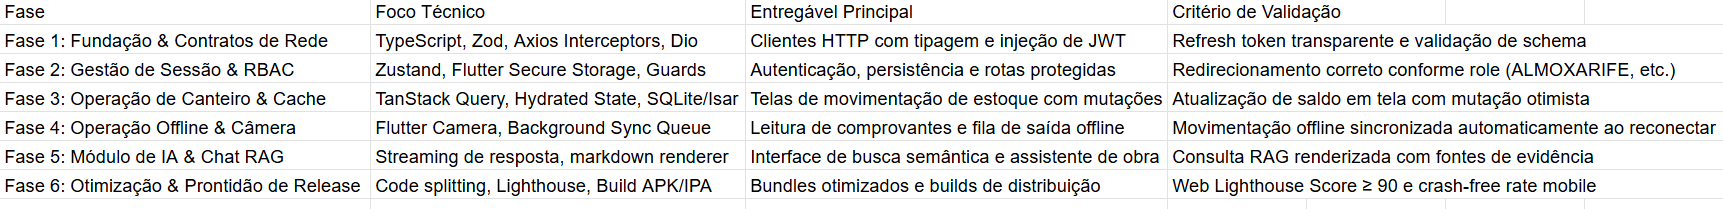

1. Matriz de Arquitetura dos Clientes

PARTE 1: Frontend Web (React + Vite + TypeScript)

Hierarquia de Execução do Frontend

[ FASE 1: Fundação de Projeto, Rede & Contratos Tipados ]

                          │
                          ▼ (Bloqueador: Interceptors de autenticação e contratos validados)

[ FASE 2: Autenticação, Persistência Segura & Controle de Acesso ]

                          │
                          ▼ (Bloqueador: Sessão preservada e rotas restritas por RBAC)

[ FASE 3: Módulos de Estoque, Movimentações & Mutações Otimistas ]

                          │
                          ▼ (Bloqueador: Baixa de estoque refletida em tela com tratamento 409)

[ FASE 4: Recursos Nativos Mobile & Sincronização Offline ]

                          │
                          ▼ (Bloqueador: Filas locais sincronizadas automaticamente via rede)

[ FASE 5: Interface do Motor de IA, RAG & Busca Semântica ]

                          │
                          ▼ (Bloqueador: Respostas semânticas e fallbacks visíveis ao usuário)

[ FASE 6: Resiliência, Otimização de Performance & Releases ]
                          │
                          
                          ▼ (Critério de Aceite Final para Publicação)

**Fase 1: Fundação de Projeto, Camada de Rede & Tipagem de Contratos**

Configuração dos clientes HTTP com injeção automática de tokens, renovação transparente (refresh token queue) e tratamento do padrão RFC 7807.

Web (React + Axios + Zod)

TypeScript

In [ ]:
// src/services/api.ts
import axios, { AxiosError, InternalAxiosRequestConfig } from 'axios';
import { z } from 'zod';

export const ApiErrorSchema = z.object({
  tipo: z.string(),
  titulo: z.string(),
  status: z.number(),
  detalhe: z.string(),
  codigo_erro: z.string(),
  correlation_id: z.string(),
  timestamp: z.string(),
});

export type ApiError = z.infer<typeof ApiErrorSchema>;

export const api = axios.create({
  baseURL: import.meta.env.VITE_API_BASE_URL || 'http://localhost:8000/api/v1',
  headers: { 'Content-Type': 'application/json' },
});

let isRefreshing = false;
let failedQueue: Array<{
  resolve: (value?: unknown) => void;
  reject: (reason?: unknown) => void;
}> = [];

const processQueue = (error: Error | null, token: string | null = null) => {
  failedQueue.forEach((prom) => {
    if (error) {
      prom.reject(error);
    } else {
      prom.resolve(token);
    }
  });
  failedQueue = [];
};

api.interceptors.request.use((config: InternalAxiosRequestConfig) => {
  const token = localStorage.getItem('@Plataforma:accessToken');
  if (token && config.headers) {
    config.headers.Authorization = `Bearer ${token}`;
  }
  return config;
});

api.interceptors.response.use(
  (response) => response,
  async (error: AxiosError) => {
    const originalRequest = error.config as InternalAxiosRequestConfig & { _retry?: boolean };

    if (error.response?.status === 401 && !originalRequest._retry) {
      if (isRefreshing) {
        return new Promise((resolve, reject) => {
          failedQueue.push({ resolve, reject });
        })
          .then((token) => {
            if (originalRequest.headers) {
              originalRequest.headers.Authorization = `Bearer ${token}`;
            }
            return api(originalRequest);
          })
          .catch((err) => Promise.reject(err));
      }

      originalRequest._retry = true;
      isRefreshing = true;

      const refreshToken = localStorage.getItem('@Plataforma:refreshToken');
      if (!refreshToken) {
        isRefreshing = false;
        return Promise.reject(error);
      }

      try {
        const { data } = await axios.post(`${api.defaults.baseURL}/auth/token/refresh/`, {
          refresh: refreshToken,
        });

        localStorage.setItem('@Plataforma:accessToken', data.access);
        processQueue(null, data.access);
        if (originalRequest.headers) {
          originalRequest.headers.Authorization = `Bearer ${data.access}`;
        }
        return api(originalRequest);
      } catch (refreshError) {
        processQueue(refreshError as Error, null);
        localStorage.removeItem('@Plataforma:accessToken');
        localStorage.removeItem('@Plataforma:refreshToken');
        window.location.href = '/login';
        return Promise.reject(refreshError);
      } finally {
        isRefreshing = false;
      }
    }

    return Promise.reject(error);
  }
);

Mobile (Flutter + Dio)

Dart

In [ ]:
// lib/core/network/api_client.dart
import 'package:dio/dio.dart';
import 'package:flutter_secure_storage/flutter_secure_storage.dart';

class ApiClient {
  late final Dio dio;
  final FlutterSecureStorage _storage = const FlutterSecureStorage();

  ApiClient() {
    dio = Dio(
      BaseOptions(
        baseUrl: 'http://10.0.2.2:8000/api/v1', // 10.0.2.2 para emulador Android
        connectTimeout: const Duration(seconds: 5),
        receiveTimeout: const Duration(seconds: 5),
        headers: {'Content-Type': 'application/json'},
      ),
    );

    dio.interceptors.add(
      QueuedInterceptorsWrapper(
        onRequest: (options, handler) async {
          final token = await _storage.read(key: 'access_token');
          if (token != null) {
            options.headers['Authorization'] = 'Bearer $token';
          }
          return handler.next(options);
        },
        onError: (DioException error, handler) async {
          if (error.response?.statusCode == 401) {
            final refreshToken = await _storage.read(key: 'refresh_token');
            if (refreshToken != null) {
              try {
                final refreshResponse = await Dio().post(
                  '${dio.options.baseUrl}/auth/token/refresh/',
                  data: {'refresh': refreshToken},
                );

                final newAccessToken = refreshResponse.data['access'];
                await _storage.write(key: 'access_token', value: newAccessToken);

                error.requestOptions.headers['Authorization'] = 'Bearer $newAccessToken';
                final clonedRequest = await dio.fetch(error.requestOptions);
                return handler.resolve(clonedRequest);
              } catch (_) {
                await _storage.deleteAll();
              }
            }
          }
          return handler.next(error);
        },
      ),
    );
  }
}

**Fase 2: Gestão de Sessão, Persistência Segura & Controle de Acesso (RBAC)
Web (Zustand Auth Store + Protected Routes)**

TypeScript

In [ ]:
// src/stores/useAuthStore.ts
import { create } from 'zustand';
import { api } from '../services/api';

export type UserRole = 'ADMINISTRADOR' | 'ENGENHEIRO_GESTOR' | 'ALMOXARIFE' | 'MESTRE_OBRA';

interface User {
  id: string;
  email: string;
  nome: string;
  empresa_id: string;
  role: UserRole;
}

interface AuthState {
  user: User | null;
  isAuthenticated: boolean;
  login: (credentials: { email: string; pass: string }) => Promise<void>;
  logout: () => void;
}

export const useAuthStore = create<AuthState>((set) => ({
  user: null,
  isAuthenticated: !!localStorage.getItem('@Plataforma:accessToken'),
  login: async ({ email, pass }) => {
    const { data } = await api.post('/auth/token/', { email, password: pass });
    localStorage.setItem('@Plataforma:accessToken', data.access);
    localStorage.setItem('@Plataforma:refreshToken', data.refresh);
    set({ user: data.user, isAuthenticated: true });
  },
  logout: () => {
    localStorage.removeItem('@Plataforma:accessToken');
    localStorage.removeItem('@Plataforma:refreshToken');
    set({ user: null, isAuthenticated: false });
  },
}));

TypeScript

In [ ]:
// src/routes/RoleGuard.tsx
import { ReactNode } from 'react';
import { Navigate } from 'react-router-dom';
import { useAuthStore, UserRole } from '../stores/useAuthStore';

interface Props {
  children: ReactNode;
  allowedRoles: UserRole[];
}

export const RoleGuard = ({ children, allowedRoles }: Props) => {
  const { user, isAuthenticated } = useAuthStore();

  if (!isAuthenticated) return <Navigate to="/login" replace />;
  if (user && !allowedRoles.includes(user.role)) return <Navigate to="/unauthorized" replace />;

  return <>{children}</>;
};

**Fase 3: Módulos de Estoque, Movimentações & Mutações Otimistas**

Implementação da saída de estoque com débito imediato na interface e rollback automático caso o backend retorne 409 Conflict.

Web (React + TanStack Query)

TypeScript

In [ ]:
// src/features/estoque/useRegistrarSaida.ts
import { useMutation, useQueryClient } from '@tanstack/react-query';
import { api } from '../../services/api';
import { AxiosError } from 'axios';

interface SaidaPayload {
  almoxarifado_id: string;
  material_id: string;
  quantidade: number;
  motivo: string;
}

interface EstoqueItem {
  id: string;
  material_id: string;
  nome: string;
  quantidade_disponivel: number;
}

export const useRegistrarSaida = (almoxarifadoId: string) => {
  const queryClient = useQueryClient();

  return useMutation({
    mutationFn: async (payload: SaidaPayload) => {
      const { data } = await api.post('/movimentacoes/saida/', payload);
      return data;
    },
    // Mutação Otimista
    onMutate: async (novoDebito) => {
      await queryClient.cancelQueries({ queryKey: ['estoque', almoxarifadoId] });
      const previousEstoque = queryClient.getQueryData<EstoqueItem[]>(['estoque', almoxarifadoId]);

      if (previousEstoque) {
        queryClient.setQueryData<EstoqueItem[]>(['estoque', almoxarifadoId], (old = []) =>
          old.map((item) =>
            item.material_id === novoDebito.material_id
              ? { ...item, quantidade_disponivel: item.quantidade_disponivel - novoDebito.quantidade }
              : item
          )
        );
      }
      return { previousEstoque };
    },
    // Rollback em caso de erro 409 (Race condition / Sem saldo)
    onError: (err: AxiosError<{ detalhe: string }>, _, context) => {
      if (context?.previousEstoque) {
        queryClient.setQueryData(['estoque', almoxarifadoId], context.previousEstoque);
      }
      alert(err.response?.data?.detalhe || 'Erro ao registrar saída de estoque.');
    },
    onSettled: () => {
      queryClient.invalidateQueries({ queryKey: ['estoque', almoxarifadoId] });
    },
  });
};

**Fase 4: Recursos Nativos Mobile, Câmera & Fila Offline**

Permite ao almoxarife registrar baixas em subsolos de obras sem sinal de internet, gravando localmente e despachando em lote ao reconectar.

Mobile (Flutter Offline Sync Engine)

Dart

In [ ]:
// lib/features/estoque/data/offline_queue_repository.dart
import 'dart:convert';
import 'package:sqflite/sqflite.dart';
import 'package:connectivity_plus/connectivity_plus.dart';
import '../../../core/network/api_client.dart';

class OfflineQueueRepository {
  final Database _db;
  final ApiClient _apiClient;

  OfflineQueueRepository(this._db, this._apiClient) {
    _initConnectivityListener();
  }

  Future<void> enfileirarMovimentacao(Map<String, dynamic> payload) async {
    await _db.insert('fila_sincronizacao', {
      'payload': jsonEncode(payload),
      'criado_em': DateTime.now().toIso8601String(),
    });
    sincronizarFila();
  }

  Future<void> sincronizarFila() async {
    final connectivity = await Connectivity().checkConnectivity();
    if (connectivity.contains(ConnectivityResult.none)) return;

    final pendentes = await _db.query('fila_sincronizacao', orderBy: 'id ASC');

    for (var item in pendentes) {
      try {
        final payload = jsonDecode(item['payload'] as String);
        final response = await _apiClient.dio.post('/movimentacoes/saida/', data: payload);

        if (response.statusCode == 201) {
          await _db.delete('fila_sincronizacao', where: 'id = ?', whereArgs: [item['id']]);
        }
      } catch (e) {
        // Interrompe para preservar a ordenação cronológica das baixas
        break;
      }
    }
  }

  void _initConnectivityListener() {
    Connectivity().onConnectivityChanged.listen((results) {
      if (!results.contains(ConnectivityResult.none)) {
        sincronizarFila();
      }
    });
  }
}

**Fase 5: Interface do Motor de IA, RAG & Busca Semântica**

Interface conversacional para o engenheiro consultar o diário de obras e insumos via linguagem natural.

Web (React + Tailwind CSS Chat RAG)

TypeScript

In [ ]:
// src/features/ia/ChatRAG.tsx
import React, { useState } from 'react';
import { api } from '../../services/api';

interface Fonte {
  tipo: string;
  referencia_id: string;
  data: string;
  score_similaridade?: number;
}

interface RAGResponse {
  pergunta: string;
  resposta_sintetizada: string;
  fontes_consultadas: Fonte[];
}

export const ChatRAG: React.FC<{ obraId: string }> = ({ obraId }) => {
  const [pergunta, setPergunta] = useState('');
  const [loading, setLoading] = useState(false);
  const [historico, setHistorico] = useState<RAGResponse[]>([]);

  const handleEnviar = async (e: React.FormEvent) => {
    e.preventDefault();
    if (!pergunta.trim() || loading) return;

    setLoading(true);
    try {
      const { data } = await api.post<RAGResponse>('/ia/rag-consulta/', {
        obra_id: obraId,
        pergunta,
      });
      setHistorico((prev) => [...prev, data]);
      setPergunta('');
    } catch {
      alert('Falha na consulta ao assistente de IA.');
    } finally {
      setLoading(false);
    }
  };

  return (
    <div className="flex flex-col h-[600px] w-full max-w-2xl bg-white border border-slate-200 rounded-lg shadow-sm">
      <div className="flex-1 p-4 overflow-y-auto space-y-4">
        {historico.map((item, idx) => (
          <div key={idx} className="space-y-2">
            <div className="bg-slate-100 p-3 rounded-lg text-slate-900 font-medium ml-auto max-w-[80%]">
              {item.pergunta}
            </div>
            <div className="bg-blue-50 border border-blue-100 p-4 rounded-lg text-slate-800 space-y-2">
              <p>{item.resposta_sintetizada}</p>
              <div className="pt-2 border-t border-blue-200 text-xs text-slate-600">
                <span className="font-semibold">Fontes Auditadas:</span>
                <ul className="list-disc list-inside mt-1 space-y-1">
                  {item.fontes_consultadas.map((f, fIdx) => (
                    <li key={fIdx}>
                      {f.tipo} - {f.data} {f.score_similaridade && `(Score: ${(f.score_similaridade * 100).toFixed(0)}%)`}
                    </li>
                  ))}
                </ul>
              </div>
            </div>
          </div>
        ))}
        {loading && <div className="text-sm text-slate-400 italic">Sintetizando informações da obra...</div>}
      </div>

      <form onSubmit={handleEnviar} className="p-3 border-t border-slate-200 flex gap-2">
        <input
          type="text"
          value={pergunta}
          onChange={(e) => setPergunta(e.target.value)}
          placeholder="Ex: Tivemos problemas de concretagem relatados no RDO da semana passada?"
          className="flex-1 px-3 py-2 border rounded-md text-sm outline-none focus:ring-2 focus:ring-blue-500"
        />
        <button
          type="submit"
          disabled={loading}
          className="px-4 py-2 bg-blue-600 text-white rounded-md text-sm font-medium hover:bg-blue-700 disabled:opacity-50"
        >
          Consultar
        </button>
      </form>
    </div>
  );
};

**Fase 6: Otimização de Performance, Telemetria & Prontidão de Release
Web (Code-Splitting e Tratamento Global de Exceções)**

TypeScript

In [ ]:
// src/App.tsx
import React, { Suspense, lazy } from 'react';
import { BrowserRouter, Routes, Route } from 'react-router-dom';
import { QueryClient, QueryClientProvider } from '@tanstack/react-query';
import { RoleGuard } from './routes/RoleGuard';

const DashboardView = lazy(() => import('./features/dashboard/DashboardView'));
const EstoqueView = lazy(() => import('./features/estoque/EstoqueView'));
const ChatRAGView = lazy(() => import('./features/ia/ChatRAGView'));

const queryClient = new QueryClient({
  defaultOptions: {
    queries: {
      retry: 1,
      refetchOnWindowFocus: false,
      staleTime: 1000 * 60 * 5, // 5 minutos
    },
  },
});

export const App: React.FC = () => {
  return (
    <QueryClientProvider client={queryClient}>
      <BrowserRouter>
        <Suspense fallback={<div className="p-6 text-center">Carregando módulo...</div>}>
          <Routes>
            <Route
              path="/estoque"
              element={
                <RoleGuard allowedRoles={['ALMOXARIFE', 'ENGENHEIRO_GESTOR']}>
                  <EstoqueView />
                </RoleGuard>
              }
            />
            <Route
              path="/ia-assistente"
              element={
                <RoleGuard allowedRoles={['ENGENHEIRO_GESTOR', 'ADMINISTRADOR']}>
                  <ChatRAGView />
                </RoleGuard>
              }
            />
            <Route path="/" element={<DashboardView />} />
          </Routes>
        </Suspense>
      </BrowserRouter>
    </QueryClientProvider>
  );
};

*Validação de Produção dos Clientes*

1. Web Build: *npm run build* gerando chunks isolados por rota com tamanho individual *< 200 kB.*

2. Mobile Build: *flutter build appbundle --release --obfuscate --split-debug-info=./symbols*

gerando pacote otimizado e seguro para distribuição.

**Para considerar a aplicação 100% validada e pronta para produção, cada camada deve retornar os seguintes resultados exatos em seus testes de aceitação:**

1. Backend e Infraestrutura (Tier 1)

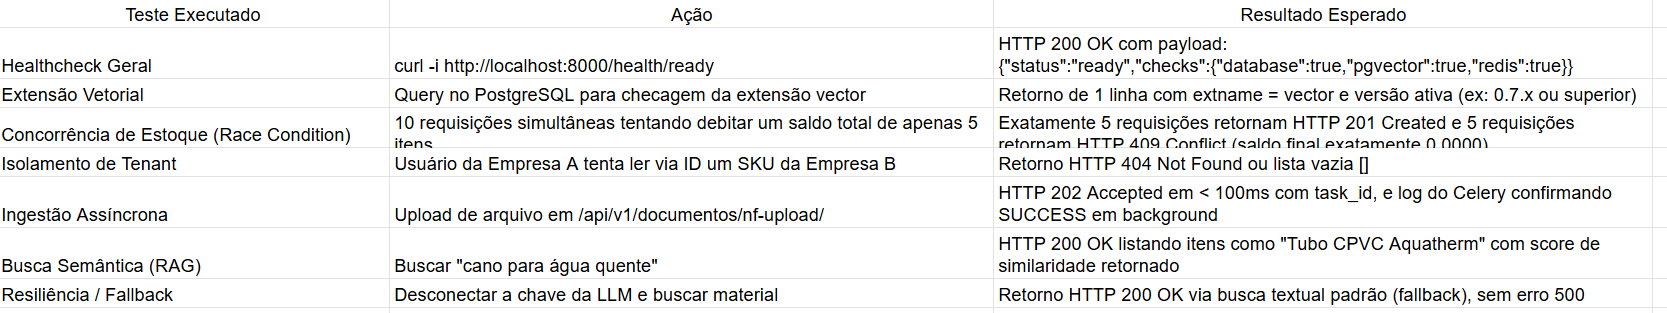

2. Frontend Web React (Tier 2)

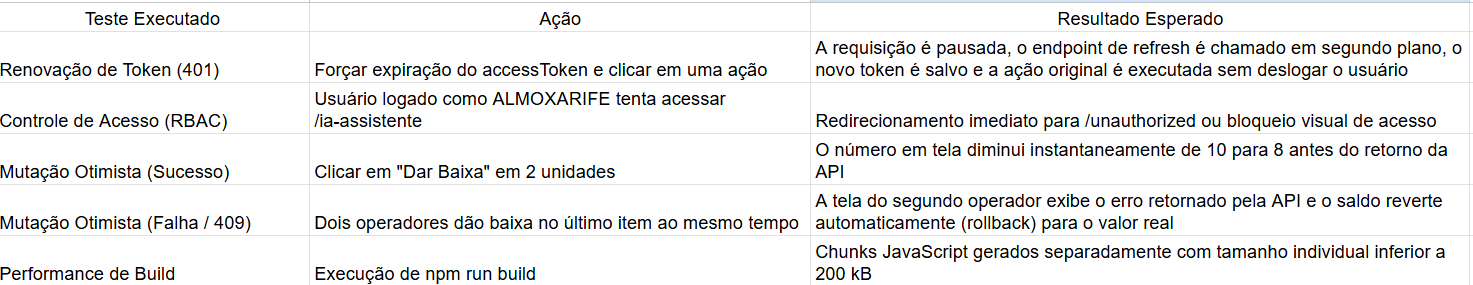

3. Mobile Flutter (Tier 2)

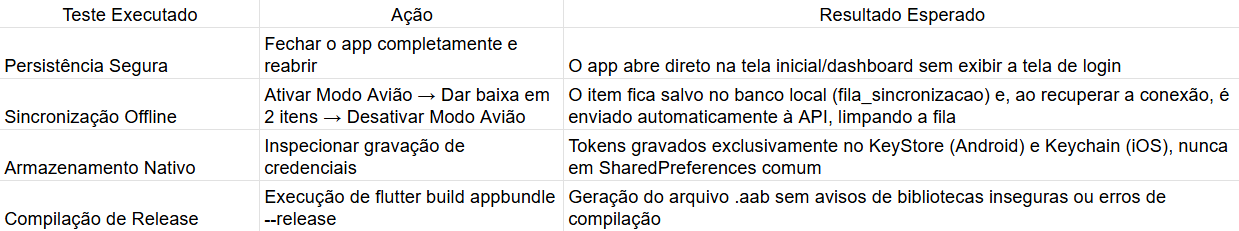

Para validar que as travas pessimistas (select_for_update) e as transações atômicas funcionam sem race condition, apresentamos duas abordagens complementares:

1. Pytest (Determinístico / CI-CD): Garante matematicamente que de $N$ requisições concorrentes, exatamente o saldo disponível recebe 201 e o excedente recebe 409.

2. Locust (Teste de Carga / Estresse): Simula múltiplos usuários virtuais simultâneos via HTTP contra o servidor rodando.

Opção 1: Validação Automatizada com Pytest (Recomendada para CI/CD)

Crie o arquivo de teste tests/test_estoque_concorrencia.py:

Python

In [ ]:
# tests/test_estoque_concorrencia.py
import pytest
from decimal import Decimal
from concurrent.futures import ThreadPoolExecutor
from django.urls import reverse
from rest_framework.test import APIClient
from rest_framework_simplejwt.tokens import RefreshToken

from apps.core.models import (
    Empresa, Usuario, Obra, Almoxarifado, MaterialCatalogo, EstoqueItem
)

@pytest.mark.django_db(transaction=True)
def test_concorrencia_saida_estoque_com_409():
    """
    Cenário:
    - Estoque inicial: 5 unidades
    - 10 requisições simultâneas requisitando 1 unidade cada
    - Resultado esperado: Exatamente 5 requisições com 201 Created e 5 com 409 Conflict
    - Saldo final no banco: exatamente 0.0000
    """
    # 1. Setup de dados de teste
    empresa = Empresa.objects.create(razao_social="Construtora Teste", cnpj="12.345.678/0001-90")
    usuario = Usuario.objects.create_user(
        username="almoxarife_teste",
        email="almoxarife@teste.com",
        password="SenhaForte123!",
        empresa=empresa,
        role=Usuario.Roles.ALMOXARIFE
    )
    obra = Obra.objects.create(empresa=empresa, nome="Residencial Horizonte", endereco="Rua 1")
    almoxarifado = Almoxarifado.objects.create(obra=obra, nome="Central")

    material = MaterialCatalogo.objects.create(
        empresa=empresa,
        codigo_sku="CIM-01",
        nome="Cimento CP II 50kg",
        unidade_medida="SACO"
    )

    estoque = EstoqueItem.objects.create(
        almoxarifado=almoxarifado,
        material=material,
        quantidade_disponivel=Decimal("5.0000"),
        ponto_ressuprimento=Decimal("2.0000")
    )

    # 2. Gerar Token JWT para autenticação
    jwt_token = str(RefreshToken.for_user(usuario).access_token)
    endpoint_url = reverse("saida_estoque")  # /api/v1/movimentacoes/saida/

    payload = {
        "almoxarifado_id": str(almoxarifado.id),
        "material_id": str(material.id),
        "quantidade": "1.0000",
        "motivo": "Teste de concorrência com Pytest"
    }

    # 3. Função executada em threads separadas (simulando múltiplos clientes HTTP)
    def disparar_requisicao():
        client = APIClient()
        client.credentials(HTTP_AUTHORIZATION=f"Bearer {jwt_token}")
        response = client.post(endpoint_url, data=payload, format="json")
        return response.status_code

    # 4. Disparar 10 requisições simultâneas via ThreadPoolExecutor
    total_requisicoes = 10
    with ThreadPoolExecutor(max_workers=total_requisicoes) as executor:
        status_codes = list(executor.map(lambda _: disparar_requisicao(), range(total_requisicoes)))

    # 5. Validação das respostas HTTP
    sucessos_201 = status_codes.count(201)
    conflitos_409 = status_codes.count(409)

    print(f"\n[Pytest Concorrência] Status 201: {sucessos_201} | Status 409: {conflitos_409}")

    assert sucessos_201 == 5, f"Esperado 5 sucessos (201), mas obteve {sucessos_201}"
    assert conflitos_409 == 5, f"Esperado 5 conflitos (409), mas obteve {conflitos_409}"

    # 6. Validação do saldo persistido no banco
    estoque.refresh_from_db()
    assert estoque.quantidade_disponivel == Decimal("0.0000"), (
        f"Saldo em estoque deveria ser 0.0000, mas ficou com {estoque.quantidade_disponivel}"
    )

Como executar o Pytest:

Bash

In [ ]:
# Executar dentro do container backend
docker compose exec backend pytest tests/test_estoque_concorrencia.py -v -s

Opção 2: Teste de Carga e Estresse com Locust

O Locust envia tráfego real contra a API em execução, avaliando o comportamento sob concorrência de múltiplos usuários virtuais.

Bash

In [ ]:
pip install locust

2. Criação do arquivo locustfile.py:

In [ ]:
# locustfile.py
from locust import HttpUser, task, between
import json

class AlmoxarifadoLoadTest(HttpUser):
    # Intervalo de espera entre requisições de cada usuário virtual (em segundos)
    wait_time = between(0.1, 0.5)

    def on_start(self):
        """Executado uma vez ao instanciar cada usuário virtual: realiza o login."""
        login_payload = {
            "email": "almoxarife@teste.com",
            "password": "SenhaForte123!"
        }
        with self.client.post("/api/v1/auth/token/", json=login_payload, catch_response=True) as resp:
            if resp.status_code == 200:
                self.access_token = resp.json()["access"]
                self.headers = {
                    "Authorization": f"Bearer {self.access_token}",
                    "Content-Type": "application/json"
                }
            else:
                resp.failure(f"Falha de autenticação no Locust: {resp.text}")

    @task
    def dar_baixa_concorrente(self):
        payload = {
            "almoxarifado_id": "8f3b2a54-6c1e-4d0f-bc1a-5b6d7e8f9a01",  # Substitua pelo ID real
            "material_id": "4e1a9b82-2d3f-4e5a-9a8b-1c2d3e4f5a6b",       # Substitua pelo ID real
            "quantidade": "1.0000",
            "motivo": "Teste de carga com Locust"
        }

        with self.client.post(
            "/api/v1/movimentacoes/saida/",
            json=payload,
            headers=self.headers,
            catch_response=True
        ) as response:
            if response.status_code == 201:
                # Baixa efetuada com sucesso
                response.success()
            elif response.status_code == 409:
                # 409 Conflict é esperado quando o estoque acaba -> NÃO deve ser marcado como erro de infra
                dados = response.json()
                if "ESTOQUE_SALDO_INSUFICIENTE" in str(dados):
                    response.success()
                else:
                    response.failure(f"409 com mensagem inesperada: {response.text}")
            elif response.status_code == 500:
                # Erro 500 indica falha de lock / deadlock no Postgres
                response.failure(f"Falha crítica no servidor (500): {response.text}")
            else:
                response.failure(f"Código HTTP inesperado: {response.status_code}")

3. Como executar o Locust:

Modo Headless (Linha de comando / CI):

Bash

In [ ]:
locust -f locustfile.py --headless -u 50 -r 10 --run-time 30s --host http://localhost:8000

-u 50: 50 usuários virtuais simultâneos.

-r 10: Taxa de subida (10 novos usuários por segundo).

--run-time 30s: Duração de 30 segundos.

Modo Interface Gráfica:

Bash

In [ ]:
locust -f locustfile.py --host http://localhost:8000

Abra http://localhost:8089 no navegador para visualizar os gráficos de RPS, latência e taxa de sucesso em tempo real.

Resultado Esperado na Validação

1. Taxa de Erros Reais (Failures): Deve ser 0%. O status 409 é classificado como resposta válida de regra de negócio (response.success()).

2. Ausência de Deadlocks (500): Nenhuma requisição deve falhar com erros de timeout de transação ou DeadlockDetected do PostgreSQL.

3. Consistência de Saldo: Ao final da execução, execute no banco de dados:

SQL

In [ ]:
SELECT quantidade_disponivel FROM core_estoqueitem WHERE id = 'ID_DO_ITEM';

O valor nunca poderá ser negativo (< 0.0000). Se o saldo inicial era 100 e foram feitas 150 requisições, o saldo final deve ser exatamente 0.0000 e a tabela core_movimentacaoitem deve conter exatamente 100 registros.

In [ ]:
import getpass
import os

# 1. Solicita o token de forma segura
token = getpass.getpass("Cole seu GitHub Personal Access Token (PAT): ").strip()
GITHUB_USERNAME = "ROSILENE05"
REPO_NAME = "plataforma-inteligente-core"

# 2. Criar a estrutura de pastas do projeto
pastas = [
    "backend/apps/core",
    "backend/apps/ia",
    "backend/config",
    "backend/tests",
    "frontend-web/src",
    "mobile-flutter/lib"
]

for p in pastas:
    os.makedirs(p, exist_ok=True)
    with open(os.path.join(p, ".gitkeep"), "w") as f:
        f.write("")

# 3. Gravar o .gitignore
with open(".gitignore", "w") as f:
    f.write(".config/\nsample_data/\n*.pyc\n__pycache__/\n*.sqlite3\n.env\n.venv/\n")

# 4. Gravar o README.md diretamente
readme_linhas = [
    "# 🏗️ Plataforma Inteligente | Almoxarifado & Gestão de Obras\n\n",
    "[![Python 3.12](https://img.shields.io/badge/Python-3.12-blue.svg)](https://www.python.org/)\n",
    "[![Django REST Framework](https://img.shields.io/badge/DRF-3.15-red.svg)](https://www.django-rest-framework.org/)\n",
    "[![PostgreSQL](https://img.shields.io/badge/PostgreSQL-16%20%2B%20pgvector-blue.svg)](https://github.com/pgvector/pgvector)\n",
    "[![React](https://img.shields.io/badge/React-19%20(Vite)-61DAFB.svg)](https://react.dev/)\n",
    "[![Flutter](https://img.shields.io/badge/Flutter-3.x-02569B.svg)](https://flutter.dev/)\n",
    "[![Docker Compose](https://img.shields.io/badge/Docker-Ready-2496ED.svg)](https://www.docker.com/)\n\n",
    "Microsserviço de alta densidade técnica projetado para transformar a gestão de almoxarifados e a rastreabilidade de materiais na construção civil. O sistema mitiga extravios e gargalos de suprimentos por meio de travas atômicas de concorrência, sincronização offline para canteiros de obras e um motor de Inteligência Artificial Generativa com busca semântica via RAG (Retrieval-Augmented Generation).\n\n",
    "## 🎯 Destaques de Engenharia & Arquitetura\n\n",
    "* **Concorrência Segura (Zero Race Conditions):** Controle transacional no banco com `select_for_update` (trava pessimista), retornando `409 Conflict` padronizado sob a RFC 7807 quando o saldo é disputado simultaneamente.\n",
    "* **Busca Semântica & RAG:** Integração nativa com `pgvector` e indexação `HNSW` com distância de cosseno (`<=>`), permitindo encontrar insumos por termos coloquiais de obra e consultar diários (RDO) em linguagem natural com fallback resiliente.\n",
    "* **Isolamento Multi-Tenant:** `TenantManager` injetado no Django ORM, garantindo segregação lógica estrita entre empresas clientes.\n",
    "* **Estratégia de Cache e Filas:** Redis como message broker para o Celery (processamento assíncrono de OCR/NF e embeddings) e cache de catálogos quentes.\n",
    "* **Mobile Offline-First:** Cliente Flutter com fila local persistida (`SQLite`), sincronizando requisições sequencialmente ao restabelecer conectividade.\n",
    "* **Mutações Otimistas no Frontend:** React com TanStack Query para atualização instantânea de saldo em tela, com mecanismo de rollback automático em respostas de erro.\n\n",
    "## 🛠️ Stack Tecnológica\n\n",
    "* **Backend:** Python 3.12, Django 5, Django REST Framework, SimpleJWT, Celery, Structlog.\n",
    "* **Banco de Dados & Vetores:** PostgreSQL 16 com extensão `pgvector`.\n",
    "* **Cache & Mensageria:** Redis 7.\n",
    "* **Frontend Web:** React 19, TypeScript, Vite, Tailwind CSS, TanStack Query, Zustand, Axios.\n",
    "* **Mobile:** Flutter 3.x, Dart, Dio, Sqflite, Flutter Secure Storage.\n",
    "* **Infraestrutura & Qualidade:** Docker, Docker Compose, Pytest, Locust, DRF-Spectacular (OpenAPI 3.0).\n\n",
    "## 🚀 Como Executar Localmente\n\n",
    "```bash\n",
    "# 1. Clonar o repositório\n",
    "git clone [https://github.com/ROSILENE05/plataforma-inteligente-core.git](https://github.com/ROSILENE05/plataforma-inteligente-core.git)\n",
    "cd plataforma-inteligente-core\n\n",
    "# 2. Subir PostgreSQL (com pgvector), Redis, Backend Django e Celery\n",
    "docker compose up --build -d\n\n",
    "# 3. Executar migrações do banco de dados\n",
    "docker compose exec backend python manage.py migrate\n",
    "```\n\n",
    "## 🧪 Validação e Testes de Concorrência\n\n",
    "```bash\n",
    "# Executar teste automatizado de race condition (esperado status 409 sob concorrência)\n",
    "docker compose exec backend pytest tests/test_estoque_concorrencia.py -v\n",
    "```\n"
]

with open("README.md", "w", encoding="utf-8") as f:
    f.writelines(readme_linhas)

# 5. Limpar arquivos padrão do Colab e fazer o push
!git rm -r --cached sample_data/ .config/ 2>/dev/null || true
!git add README.md .gitignore backend/ frontend-web/ mobile-flutter/
!git commit -m "docs: add complete architectural README and scaffold"
!git remote set-url origin https://{token}@github.com/{GITHUB_USERNAME}/{REPO_NAME}.git
!git push origin main --force

print(f"\n✅ Concluído! Acesse seu repositório atualizado:")
print(f"🔗 https://github.com/{GITHUB_USERNAME}/{REPO_NAME}")

Cole seu GitHub Personal Access Token (PAT): ··········
rm '.config/.last_opt_in_prompt.yaml'
rm '.config/.last_survey_prompt.yaml'
rm '.config/.last_update_check.json'
rm '.config/active_config'
rm '.config/config_sentinel'
rm '.config/configurations/config_default'
rm '.config/default_configs.db'
rm '.config/gce'
rm '.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db'
rm '.config/logs/2026.08.20/13.28.54.805602.log'
rm '.config/logs/2026.08.20/13.29.20.653977.log'
rm '.config/logs/2026.08.20/13.29.32.576803.log'
rm '.config/logs/2026.08.20/13.29.34.381367.log'
rm '.config/logs/2026.08.20/13.29.45.182906.log'
rm '.config/logs/2026.08.20/13.29.46.035673.log'
rm 'sample_data/README.md'
rm 'sample_data/anscombe.json'
rm 'sample_data/california_housing_test.csv'
rm 'sample_data/california_housing_train.csv'
rm 'sample_data/mnist_test.csv'
rm 'sample_data/mnist_train_small.csv'
[main bb85edb] docs: add complete architectural README and scaffold
 28 files changed, 51 ins